# CCS 230 – Final Project
## Data Mining for Heart Disease Pattern Discovery and Risk Prediction

**Group Members:**
- Shane D. Canabo
- Myrrhea Belle B. Junsay
- Kyla Elijah C. Ramiro
- Meagelleine Rose S. Sionosa
- Athena S. Villarin


---
## Imports

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, silhouette_score
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
%matplotlib inline

---
# PHASE 1: Business & Data Understanding

## 1.1 Load Dataset

In [2]:
df = pd.read_csv('data/heart.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 1.2 Descriptive Statistics

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
# Check for missing values
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [6]:
# Target distribution
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

## 1.3 Visualizations

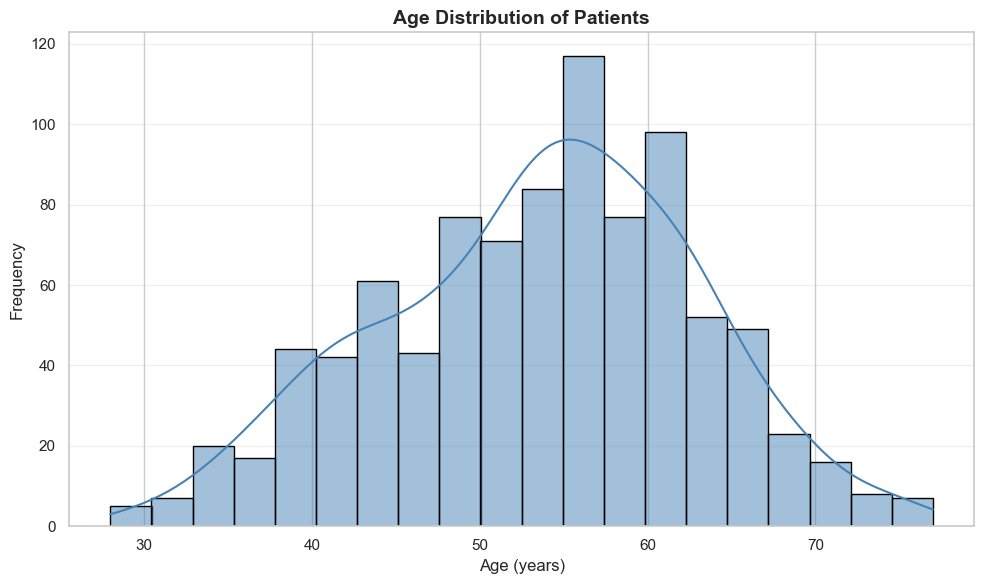

Age Statistics:
  Mean: 53.5 years
  Median: 54.0 years
  Std Dev: 9.4 years
  Range: 28-77 years


In [7]:
# TODO: Age distribution
# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', bins=20, kde=True, color='steelblue', edgecolor='black')
plt.title('Age Distribution of Patients', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print(f'Age Statistics:')
print(f'  Mean: {df["Age"].mean():.1f} years')
print(f'  Median: {df["Age"].median():.1f} years')
print(f'  Std Dev: {df["Age"].std():.1f} years')
print(f'  Range: {df["Age"].min()}-{df["Age"].max()} years')

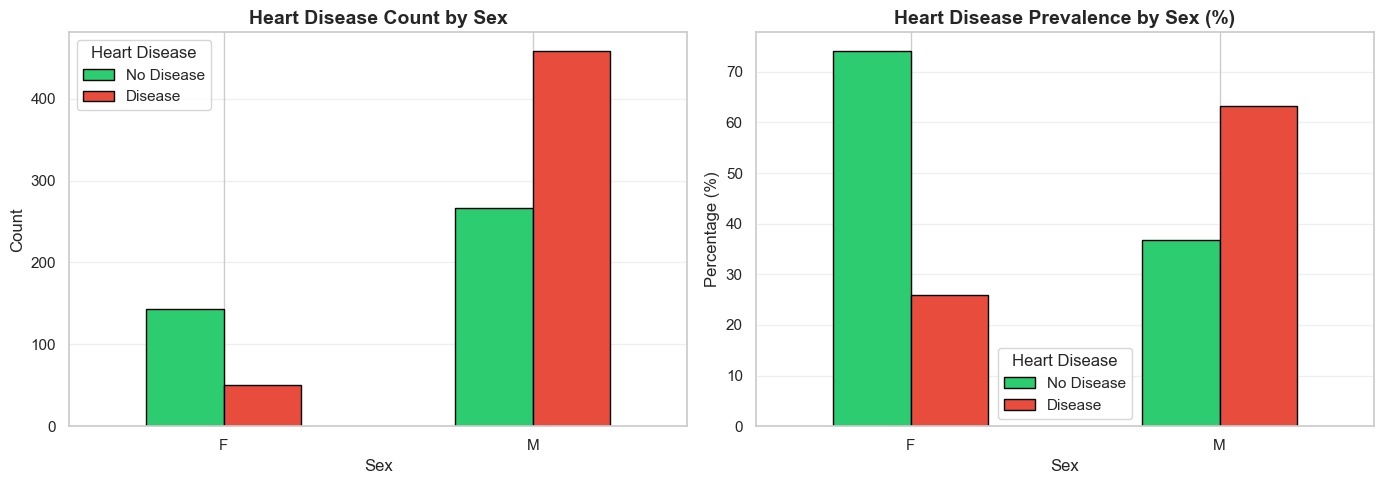

Heart Disease by Sex:
HeartDisease    0    1
Sex                   
F             143   50
M             267  458

Heart Disease Prevalence by Sex (%):
HeartDisease      0      1
Sex                       
F             74.09  25.91
M             36.83  63.17


In [8]:
# TODO: Heart Disease count by Sex
# Heart Disease count by Sex
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Stacked count plot
sex_disease = pd.crosstab(df['Sex'], df['HeartDisease'])
sex_disease.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Heart Disease Count by Sex', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sex', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(['No Disease', 'Disease'], title='Heart Disease')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Proportion/percentage plot
sex_disease_pct = pd.crosstab(df['Sex'], df['HeartDisease'], normalize='index') * 100
sex_disease_pct.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Heart Disease Prevalence by Sex (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sex', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(['No Disease', 'Disease'], title='Heart Disease')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print('Heart Disease by Sex:')
print(sex_disease)
print('\nHeart Disease Prevalence by Sex (%):')
print(sex_disease_pct.round(2))

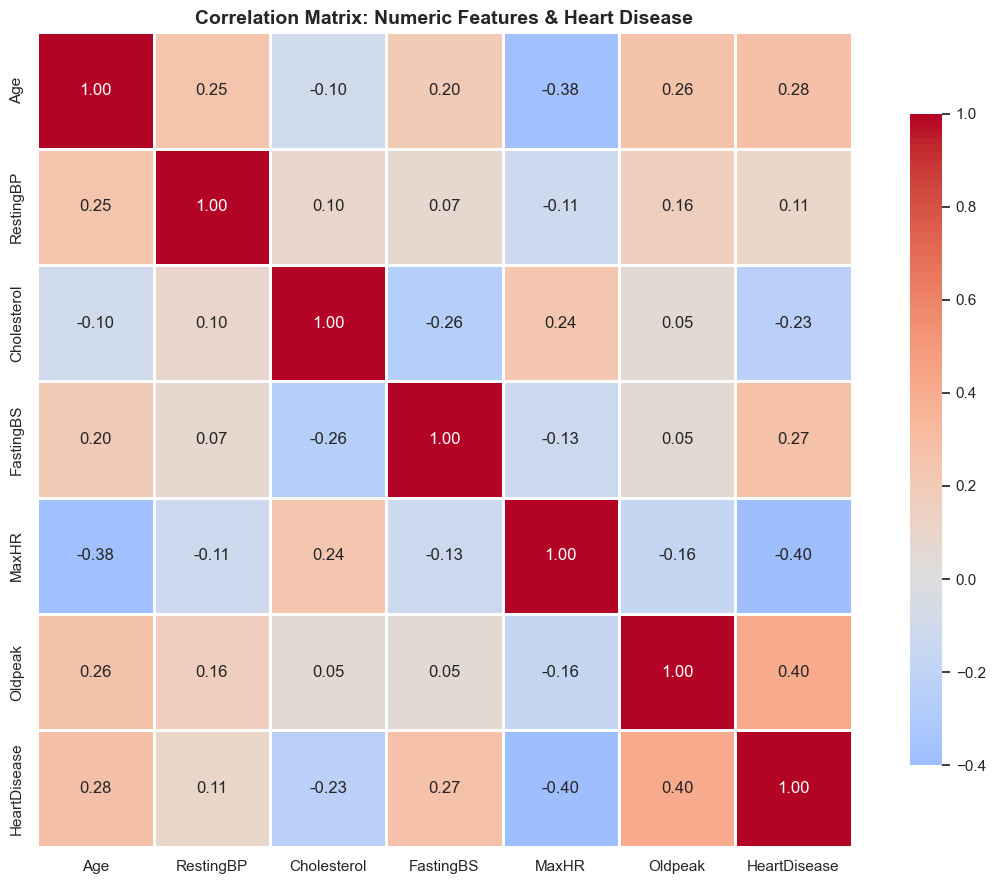


Correlations with Heart Disease (sorted by strength):
HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.107589
Cholesterol    -0.232741
MaxHR          -0.400421
Name: HeartDisease, dtype: float64

Strong Correlations with Heart Disease (|r| > 0.3):
Oldpeak    0.403951
MaxHR     -0.400421
Name: HeartDisease, dtype: float64


In [9]:
# TODO: Correlation heatmap (numeric columns)
# Correlation heatmap (numeric columns)
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

# Create figure
plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Numeric Features & Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Extract correlations with HeartDisease (sorted by absolute value)
print('\nCorrelations with Heart Disease (sorted by strength):')
disease_correlations = correlation_matrix['HeartDisease'].sort_values(ascending=False)
print(disease_correlations)

# Highlight strong correlations (|r| > 0.3)
print('\nStrong Correlations with Heart Disease (|r| > 0.3):')
strong_corr = disease_correlations[(abs(disease_correlations) > 0.3) & (disease_correlations.index != 'HeartDisease')]
print(strong_corr.sort_values(ascending=False))

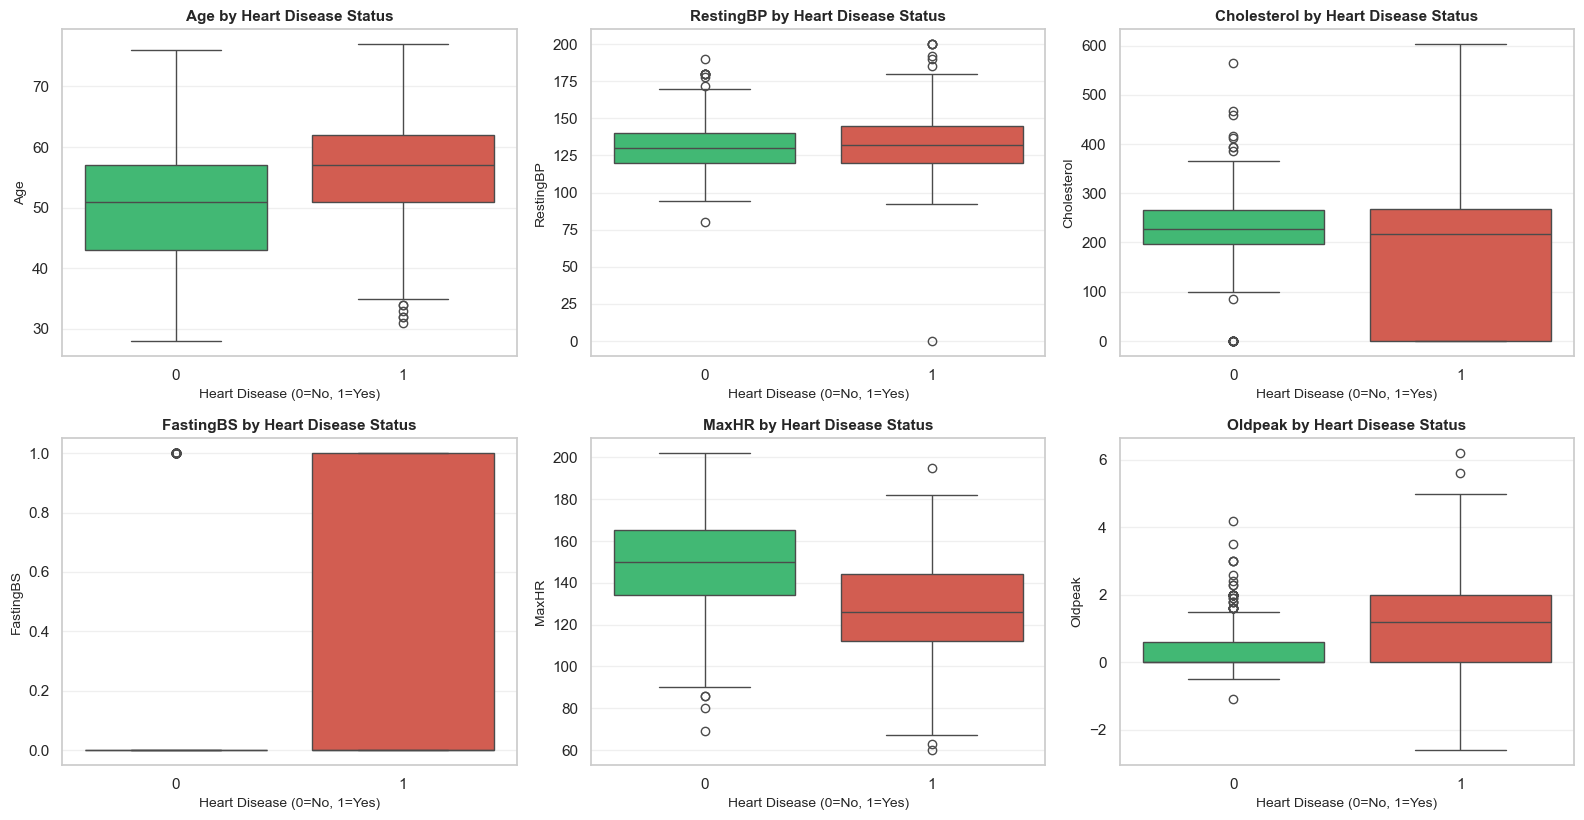

Boxplot Analysis: Median differences between disease/no-disease groups



In [10]:
# TODO: Additional visualizations (boxplots, bar charts per categorical feature)
# Additional visualizations (boxplots, bar charts per categorical feature)

# 1. BOXPLOTS: Continuous features by Heart Disease status
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('HeartDisease')  # Remove target from features

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    sns.boxplot(data=df, x='HeartDisease', y=feature, ax=axes[idx], palette=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'{feature} by Heart Disease Status', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Heart Disease (0=No, 1=Yes)', fontsize=10)
    axes[idx].set_ylabel(feature, fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

# Hide unused subplots
for idx in range(len(numeric_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print('Boxplot Analysis: Median differences between disease/no-disease groups\n')


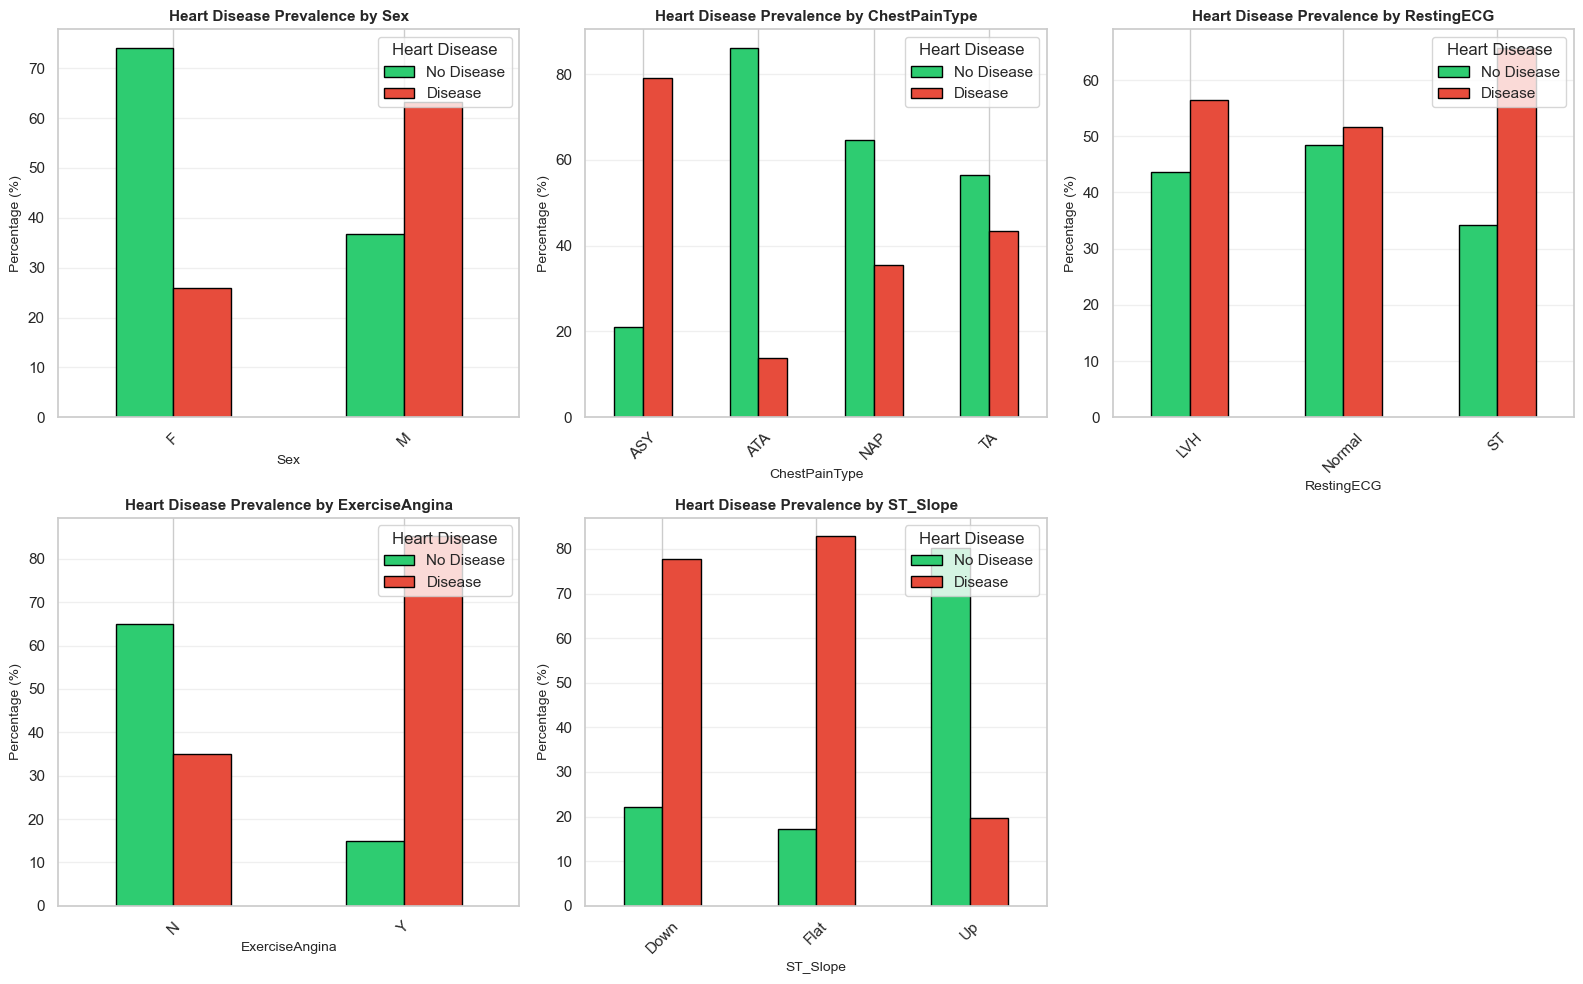

In [11]:
# 2. BAR CHARTS: Categorical features by Heart Disease
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    # Create crosstab and normalize
    cat_disease = pd.crosstab(df[feature], df['HeartDisease'], normalize='index') * 100
    cat_disease.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[idx].set_title(f'Heart Disease Prevalence by {feature}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Percentage (%)', fontsize=10)
    axes[idx].legend(['No Disease', 'Disease'], title='Heart Disease', loc='upper right')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

# Hide unused subplots
for idx in range(len(categorical_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
# 3. SUMMARY STATISTICS
print('\n' + '='*60)
print('CATEGORICAL FEATURE BREAKDOWN')
print('='*60)
for feature in categorical_features:
    print(f'\n{feature}:')
    cat_summary = pd.crosstab(df[feature], df['HeartDisease'], margins=True)
    print(cat_summary)
    
    # Disease prevalence per category
    cat_pct = pd.crosstab(df[feature], df['HeartDisease'], normalize='index') * 100
    print(f'\nDisease Prevalence (%):\n{cat_pct[1].round(2)}')

print('\n' + '='*60)
print('NUMERIC FEATURE STATISTICS BY DISEASE STATUS')
print('='*60)
for feature in numeric_features:
    print(f'\n{feature}:')
    print(df.groupby('HeartDisease')[feature].agg(['mean', 'median', 'std', 'min', 'max']).round(2))


CATEGORICAL FEATURE BREAKDOWN

Sex:
HeartDisease    0    1  All
Sex                        
F             143   50  193
M             267  458  725
All           410  508  918

Disease Prevalence (%):
Sex
F    25.91
M    63.17
Name: 1, dtype: float64

ChestPainType:
HeartDisease     0    1  All
ChestPainType               
ASY            104  392  496
ATA            149   24  173
NAP            131   72  203
TA              26   20   46
All            410  508  918

Disease Prevalence (%):
ChestPainType
ASY    79.03
ATA    13.87
NAP    35.47
TA     43.48
Name: 1, dtype: float64

RestingECG:
HeartDisease    0    1  All
RestingECG                 
LVH            82  106  188
Normal        267  285  552
ST             61  117  178
All           410  508  918

Disease Prevalence (%):
RestingECG
LVH       56.38
Normal    51.63
ST        65.73
Name: 1, dtype: float64

ExerciseAngina:
HeartDisease      0    1  All
ExerciseAngina               
N               355  192  547
Y                5

---
# PHASE 2: Data Preparation & Modeling

## 2.1 Data Cleaning & Preparation

In [13]:
# TODO: One-Hot Encoding for categorical features
# One-Hot Encoding for categorical features

# Create a copy for encoding
df_encoded = df.copy()

# Identify categorical columns
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns to encode: {categorical_cols}\n')

# Display original categorical features
print('Original categorical features:')
for col in categorical_cols:
    print(f'  {col}: {df_encoded[col].unique()}')

# Apply one-hot encoding (drop_first=True to avoid multicollinearity)
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

print(f'\nOriginal shape: {df.shape}')
print(f'Encoded shape: {df_encoded.shape}')
print(f'\nEncoded dataframe columns:')
print(df_encoded.columns.tolist())

# Display first few rows
print('\nFirst 5 rows of encoded data:')
print(df_encoded.head())

# Show info about encoded data
print('\nEncoded data info:')
print(df_encoded.info())

# Verify no missing values
print(f'\nMissing values in encoded data:\n{df_encoded.isnull().sum()}')

Categorical columns to encode: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Original categorical features:
  Sex: ['M' 'F']
  ChestPainType: ['ATA' 'NAP' 'ASY' 'TA']
  RestingECG: ['Normal' 'ST' 'LVH']
  ExerciseAngina: ['N' 'Y']
  ST_Slope: ['Up' 'Flat' 'Down']

Original shape: (918, 12)
Encoded shape: (918, 16)

Encoded dataframe columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']

First 5 rows of encoded data:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40        140          289          0    172      0.0             0   
1   49        160          180          0    156      1.0             1   
2   37        130          283          0     98      0.0             0   
3   48        138          214          0    108      1

In [14]:
# TODO: Discretization / Binning of continuous features (for Association Rule Mining)
# Discretization / Binning of continuous features (for Association Rule Mining)

# Create a copy of original dataframe for binning
df_binned = df.copy()

# Define binning strategies for continuous features
print('Discretizing continuous features for Association Rule Mining:\n')

# 1. Age: Bin into age groups (clinical relevance)
df_binned['Age_Group'] = pd.cut(df_binned['Age'], 
                                 bins=[0, 30, 40, 50, 60, 100], 
                                 labels=['<30', '30-40', '40-50', '50-60', '60+'])
print("Age Groups:")
print(df_binned['Age_Group'].value_counts().sort_index())

# 2. Cholesterol: Clinical thresholds (mg/dL)
# 0 = unknown, <200 = desirable, 200-239 = borderline, >=240 = high
df_binned['Cholesterol_Level'] = pd.cut(df_binned['Cholesterol'],
                                         bins=[0, 1, 200, 240, np.inf],
                                         labels=['Unknown', 'Desirable', 'Borderline', 'High'],
                                         include_lowest=True)
print("\nCholesterol Levels:")
print(df_binned['Cholesterol_Level'].value_counts().sort_index())

# 3. RestingBP: Clinical thresholds (mmHg)
# 0 = unknown, <120 = normal, 120-139 = elevated, >=140 = high
df_binned['BP_Level'] = pd.cut(df_binned['RestingBP'],
                                bins=[0, 1, 120, 140, np.inf],
                                labels=['Unknown', 'Normal', 'Elevated', 'High'],
                                include_lowest=True)
print("\nBlood Pressure Levels:")
print(df_binned['BP_Level'].value_counts().sort_index())

# 4. MaxHR: Equal-frequency binning (quartiles)
df_binned['MaxHR_Range'] = pd.qcut(df_binned['MaxHR'], 
                                    q=4, 
                                    labels=['Very Low', 'Low', 'Moderate', 'High'],
                                    duplicates='drop')
print("\nMax Heart Rate Ranges:")
print(df_binned['MaxHR_Range'].value_counts().sort_index())

# 5. Oldpeak (ST depression): Clinical significance
# 0 = no depression, <1 = minimal, 1-2 = moderate, >2 = significant
df_binned['STDepression_Level'] = pd.cut(df_binned['Oldpeak'],
                                          bins=[-0.1, 0.1, 1, 2, np.inf],
                                          labels=['None', 'Minimal', 'Moderate', 'Significant'],
                                          include_lowest=True)
print("\nST Depression Levels:")
print(df_binned['STDepression_Level'].value_counts().sort_index())

# Drop original continuous columns and keep only categorical
binned_features = ['Age_Group', 'Cholesterol_Level', 'BP_Level', 'MaxHR_Range', 
                   'STDepression_Level', 'Sex', 'ChestPainType', 'FastingBS', 
                   'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

df_binned_final = df_binned[binned_features].copy()

print(f'\n{"="*60}')
print(f'Original continuous features: Age, Cholesterol, RestingBP, MaxHR, Oldpeak')
print(f'Binned dataset shape: {df_binned_final.shape}')
print(f'All features are now categorical')
print(f'{"="*60}')

print('\nBinned dataset preview:')
print(df_binned_final.head(10))

# Display correlation/relationship of binned Age with Heart Disease
print('\n' + '='*60)
print('BINNED FEATURES SUMMARY')
print('='*60)
print('\nAge Group vs Heart Disease:')
print(pd.crosstab(df_binned['Age_Group'], df_binned['HeartDisease'], margins=True))

print('\nCholesterol Level vs Heart Disease:')
print(pd.crosstab(df_binned['Cholesterol_Level'], df_binned['HeartDisease'], margins=True))

print('\nBlood Pressure Level vs Heart Disease:')
print(pd.crosstab(df_binned['BP_Level'], df_binned['HeartDisease'], margins=True))

Discretizing continuous features for Association Rule Mining:

Age Groups:
Age_Group
<30        5
30-40     88
40-50    223
50-60    381
60+      221
Name: count, dtype: int64

Cholesterol Levels:
Cholesterol_Level
Unknown       172
Desirable     150
Borderline    241
High          355
Name: count, dtype: int64

Blood Pressure Levels:
BP_Level
Unknown       1
Normal      292
Elevated    405
High        220
Name: count, dtype: int64

Max Heart Rate Ranges:
MaxHR_Range
Very Low    261
Low         204
Moderate    232
High        221
Name: count, dtype: int64

ST Depression Levels:
STDepression_Level
None           384
Minimal        190
Moderate       233
Significant    100
Name: count, dtype: int64

Original continuous features: Age, Cholesterol, RestingBP, MaxHR, Oldpeak
Binned dataset shape: (918, 12)
All features are now categorical

Binned dataset preview:
  Age_Group Cholesterol_Level  BP_Level MaxHR_Range STDepression_Level Sex  \
0     30-40              High  Elevated        High

## 2.2 Association Rule Mining

In [15]:
# Prepare one-hot encoded transaction dataset for Apriori

# Work from the binned categorical dataset
arm_df = df_binned_final.copy()
arm_df['HeartDisease'] = arm_df['HeartDisease'].map({0: 'No', 1: 'Yes'})

# Build transactions in Feature=Value format
transactions = arm_df.astype(str).apply(
    lambda row: [f"{col}={row[col]}" for col in arm_df.columns],
    axis=1
).tolist()

# One-hot transaction matrix
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
transaction_df = pd.DataFrame(te_array, columns=te.columns_)

print(f'Total transactions: {len(transactions)}')
print(f'Total encoded items: {transaction_df.shape[1]}')
print('\nSample transaction items:')
print(transactions[0][:8])
transaction_df.head()

Total transactions: 918
Total encoded items: 40

Sample transaction items:
['Age_Group=30-40', 'Cholesterol_Level=High', 'BP_Level=Elevated', 'MaxHR_Range=High', 'STDepression_Level=None', 'Sex=M', 'ChestPainType=ATA', 'FastingBS=0']


,Age_Group=30-40,Age_Group=40-50,Age_Group=50-60,Age_Group=60+,Age_Group=<30,BP_Level=Elevated,BP_Level=High,BP_Level=Normal,BP_Level=Unknown,ChestPainType=ASY,...,STDepression_Level=Minimal,STDepression_Level=Moderate,STDepression_Level=None,STDepression_Level=Significant,STDepression_Level=nan,ST_Slope=Down,ST_Slope=Flat,ST_Slope=Up,Sex=F,Sex=M
0,True,False,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,True,False,True
1,False,True,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,True,False,True,False
2,True,False,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,True,False,True
3,False,True,False,False,False,True,False,False,False,True,...,False,True,False,False,False,False,True,False,True,False
4,False,False,True,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,True


In [16]:
# Run Apriori algorithm

# Use a practical support value that balances signal and interpretability
min_support = 0.10
frequent_itemsets = apriori(
    transaction_df,
    min_support=min_support,
    use_colnames=True
).sort_values('support', ascending=False).reset_index(drop=True)

frequent_itemsets['itemset_len'] = frequent_itemsets['itemsets'].apply(len)

print(f'Min support used: {min_support}')
print(f'Frequent itemsets found: {len(frequent_itemsets)}')
print('\nTop frequent itemsets:')
frequent_itemsets.head(10)

Min support used: 0.1
Frequent itemsets found: 1176

Top frequent itemsets:


,support,itemsets,itemset_len
0,0.789760,(Sex=M),1
1,0.766885,(FastingBS=0),1
2,0.601307,(RestingECG=Normal),1
3,0.595861,(ExerciseAngina=N),1
4,0.584967,"(Sex=M, FastingBS=0)",2
5,0.553377,(HeartDisease=Yes),1
6,0.540305,(ChestPainType=ASY),1
7,0.501089,(ST_Slope=Flat),1
8,0.498911,"(Sex=M, HeartDisease=Yes)",2
9,0.480392,"(RestingECG=Normal, FastingBS=0)",2


In [17]:
# Generate association rules and filter for HeartDisease as consequent

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.60
).copy()

# Keep rules predicting heart disease presence
heart_rules = rules[rules['consequents'].apply(lambda x: 'HeartDisease=Yes' in x)].copy()
heart_rules = heart_rules[heart_rules['antecedents'].apply(len) > 0]

# Human-readable itemset text
heart_rules['antecedent_text'] = heart_rules['antecedents'].apply(
    lambda x: ', '.join(sorted(list(x)))
)
heart_rules['consequent_text'] = heart_rules['consequents'].apply(
    lambda x: ', '.join(sorted(list(x)))
)

heart_rules = heart_rules.sort_values(
    by=['lift', 'confidence', 'support'],
    ascending=[False, False, False]
).reset_index(drop=True)

print(f'Total rules generated: {len(rules)}')
print(f'Rules with HeartDisease=Yes as consequent: {len(heart_rules)}')

heart_rules[['antecedent_text', 'consequent_text', 'support', 'confidence', 'lift']].head(10)

Total rules generated: 3904
Rules with HeartDisease=Yes as consequent: 523


,antecedent_text,consequent_text,support,confidence,lift
0,"ChestPainType=ASY, STDepression_Level=Moderate...","ExerciseAngina=Y, HeartDisease=Yes",0.111111,0.728571,2.116546
1,"ChestPainType=ASY, MaxHR_Range=Very Low, ST_Sl...","ExerciseAngina=Y, HeartDisease=Yes, Sex=M",0.103486,0.664336,2.110243
2,"ChestPainType=ASY, MaxHR_Range=Very Low, ST_Sl...","ExerciseAngina=Y, HeartDisease=Yes",0.103486,0.714286,2.075045
3,"ChestPainType=ASY, STDepression_Level=Moderate","ExerciseAngina=Y, HeartDisease=Yes",0.123094,0.706250,2.051701
4,"ChestPainType=ASY, FastingBS=0, MaxHR_Range=Ve...","ExerciseAngina=Y, HeartDisease=Yes",0.102397,0.701493,2.037880
5,"ChestPainType=ASY, STDepression_Level=Moderate","ExerciseAngina=Y, HeartDisease=Yes, Sex=M",0.111111,0.637500,2.025000
6,"ChestPainType=ASY, FastingBS=0, ST_Slope=Flat,...","ExerciseAngina=Y, HeartDisease=Yes",0.142702,0.693122,2.013562
7,"ChestPainType=ASY, MaxHR_Range=Very Low, ST_Sl...","ExerciseAngina=Y, HeartDisease=Yes",0.107843,0.692308,2.011198
8,"STDepression_Level=Moderate, ST_Slope=Flat, Sex=M","ExerciseAngina=Y, HeartDisease=Yes",0.106754,0.690141,2.004903
9,"ChestPainType=ASY, MaxHR_Range=Very Low","ExerciseAngina=Y, HeartDisease=Yes, Sex=M",0.131808,0.630208,2.001838


In [18]:
# Display top rules sorted by confidence/lift

if heart_rules.empty:
    print('No heart-disease rules found at current thresholds. Lower support/confidence thresholds and rerun.')
else:
    top_rules_lift = heart_rules.nlargest(10, 'lift')[
        ['antecedent_text', 'support', 'confidence', 'lift']
    ]
    top_rules_conf = heart_rules.nlargest(10, 'confidence')[
        ['antecedent_text', 'support', 'confidence', 'lift']
    ]

    print('Top 10 Rules by Lift:')
    display(top_rules_lift.style.format({
        'support': '{:.3f}',
        'confidence': '{:.3f}',
        'lift': '{:.3f}'
    }))

    print('\nTop 10 Rules by Confidence:')
    display(top_rules_conf.style.format({
        'support': '{:.3f}',
        'confidence': '{:.3f}',
        'lift': '{:.3f}'
    }))

Top 10 Rules by Lift:


,antecedent_text,support,confidence,lift
0,"ChestPainType=ASY, STDepression_Level=Moderate, Sex=M",0.111,0.729,2.117
1,"ChestPainType=ASY, MaxHR_Range=Very Low, ST_Slope=Flat",0.103,0.664,2.110
2,"ChestPainType=ASY, MaxHR_Range=Very Low, ST_Slope=Flat, Sex=M",0.103,0.714,2.075
3,"ChestPainType=ASY, STDepression_Level=Moderate",0.123,0.706,2.052
4,"ChestPainType=ASY, FastingBS=0, MaxHR_Range=Very Low",0.102,0.701,2.038
5,"ChestPainType=ASY, STDepression_Level=Moderate",0.111,0.637,2.025
6,"ChestPainType=ASY, FastingBS=0, ST_Slope=Flat, Sex=M",0.143,0.693,2.014
7,"ChestPainType=ASY, MaxHR_Range=Very Low, ST_Slope=Flat",0.108,0.692,2.011
8,"STDepression_Level=Moderate, ST_Slope=Flat, Sex=M",0.107,0.690,2.005
9,"ChestPainType=ASY, MaxHR_Range=Very Low",0.132,0.630,2.002



Top 10 Rules by Confidence:


,antecedent_text,support,confidence,lift
61,"ChestPainType=ASY, FastingBS=1, ST_Slope=Flat",0.101,1.000,1.807
82,"ChestPainType=ASY, MaxHR_Range=Very Low, ST_Slope=Flat, Sex=M",0.141,0.970,1.753
84,"BP_Level=High, ChestPainType=ASY, ST_Slope=Flat",0.101,0.969,1.751
97,"Cholesterol_Level=Unknown, ST_Slope=Flat",0.111,0.962,1.739
102,"ChestPainType=ASY, STDepression_Level=Moderate, ST_Slope=Flat, Sex=M",0.107,0.961,1.736
104,"Cholesterol_Level=Unknown, ST_Slope=Flat, Sex=M",0.106,0.960,1.736
105,"MaxHR_Range=Very Low, RestingECG=Normal, ST_Slope=Flat, Sex=M",0.105,0.960,1.735
106,"ChestPainType=ASY, ExerciseAngina=Y, MaxHR_Range=Very Low, ST_Slope=Flat, Sex=M",0.103,0.960,1.734
110,"ChestPainType=ASY, MaxHR_Range=Very Low, ST_Slope=Flat",0.149,0.958,1.731
115,"ChestPainType=ASY, ExerciseAngina=Y, RestingECG=Normal, ST_Slope=Flat, Sex=M",0.113,0.954,1.724


## 2.3 Classification Modeling

In [19]:
# Define features (X) and target (y), then train-test split

X = df_encoded.drop(columns=['HeartDisease'])
y = df_encoded['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'X shape: {X.shape}')
print(f'Train shape: {X_train.shape} | Test shape: {X_test.shape}')
print('\nTarget distribution (train):')
print(y_train.value_counts(normalize=True).round(3))
print('\nTarget distribution (test):')
print(y_test.value_counts(normalize=True).round(3))

X shape: (918, 15)
Train shape: (734, 15) | Test shape: (184, 15)

Target distribution (train):
HeartDisease
1    0.553
0    0.447
Name: proportion, dtype: float64

Target distribution (test):
HeartDisease
1    0.554
0    0.446
Name: proportion, dtype: float64


### 2.3.1 Decision Tree

In [20]:
# Train Decision Tree

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=8,
    random_state=42,
    class_weight='balanced'
 )
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print('Decision Tree Performance (initial):')
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_dt):.4f}")

Decision Tree Performance (initial):
Accuracy : 0.8315
Precision: 0.8817
Recall   : 0.8039
F1-score : 0.8410


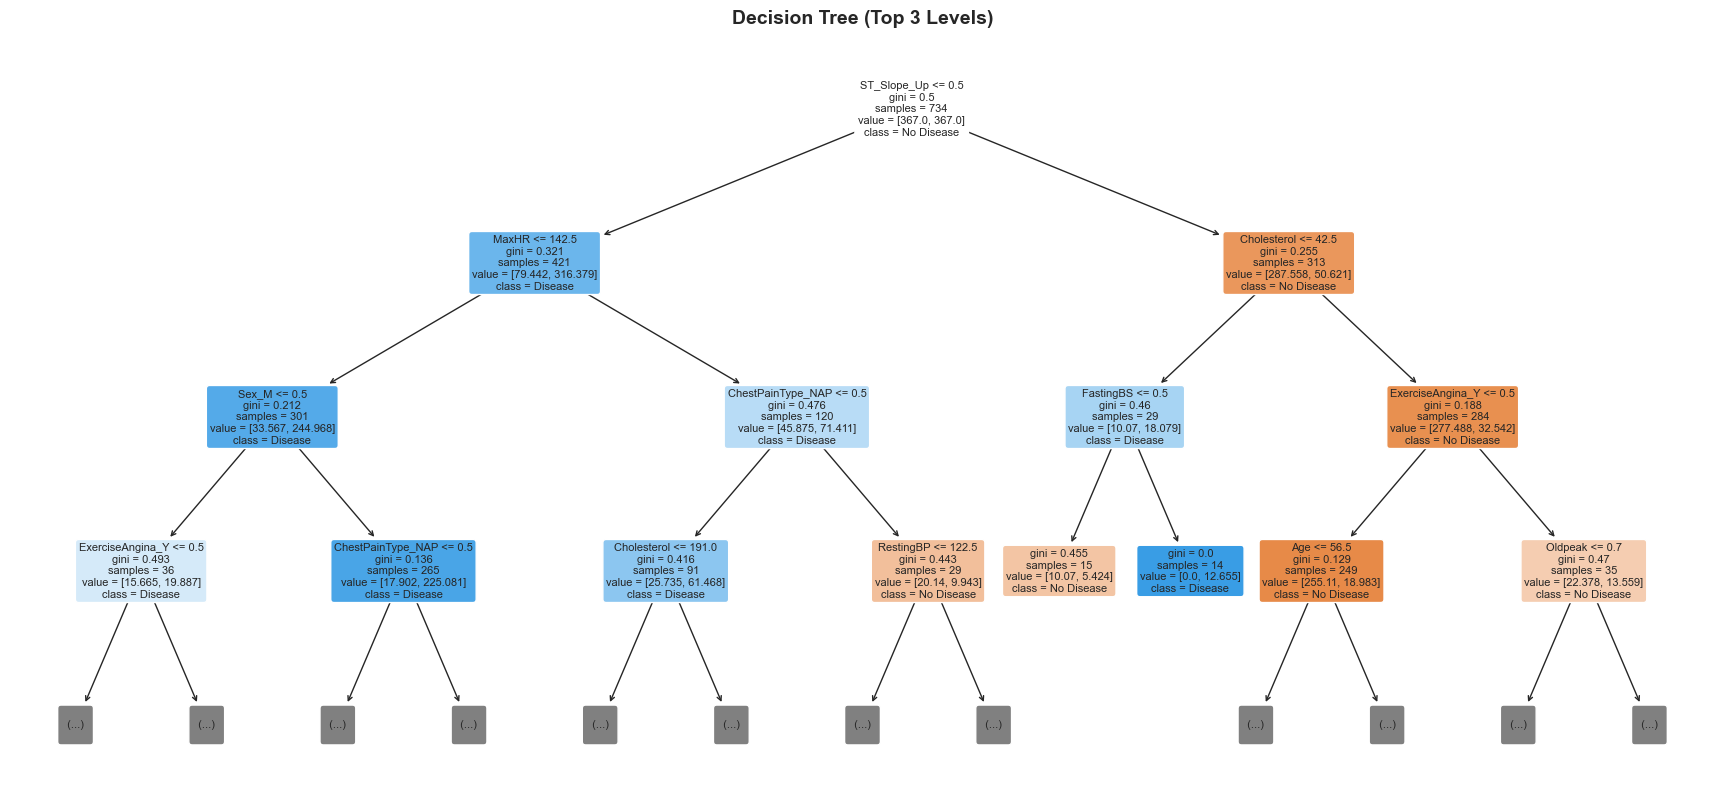

In [21]:
# Plot Decision Tree

plt.figure(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
 )
plt.title('Decision Tree (Top 3 Levels)', fontsize=14, fontweight='bold')
plt.show()

In [22]:
# Extract readable rules from Decision Tree

tree_rules = export_text(dt_model, feature_names=list(X.columns))
print('Readable Decision Tree Rules:')
print(tree_rules)

Readable Decision Tree Rules:
|--- ST_Slope_Up <= 0.50
|   |--- MaxHR <= 142.50
|   |   |--- Sex_M <= 0.50
|   |   |   |--- ExerciseAngina_Y <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- ExerciseAngina_Y >  0.50
|   |   |   |   |--- Age <= 53.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Age >  53.50
|   |   |   |   |   |--- class: 1
|   |   |--- Sex_M >  0.50
|   |   |   |--- ChestPainType_NAP <= 0.50
|   |   |   |   |--- Cholesterol <= 222.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Cholesterol >  222.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- ChestPainType_NAP >  0.50
|   |   |   |   |--- Age <= 58.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Age >  58.50
|   |   |   |   |   |--- class: 1
|   |--- MaxHR >  142.50
|   |   |--- ChestPainType_NAP <= 0.50
|   |   |   |--- Cholesterol <= 191.00
|   |   |   |   |--- class: 1
|   |   |   |--- Cholesterol >  191.00
|   |   |   |   |--- Cholesterol <= 227.50
|   |   |   |   |   |--- 

### 2.3.2 Random Forest

In [23]:
# Train Random Forest

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=4,
    random_state=42,
    class_weight='balanced_subsample'
 )
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print('Random Forest Performance (initial):')
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_rf):.4f}")

# Save trained models for dashboard use
os.makedirs('models', exist_ok=True)
joblib.dump(dt_model, 'models/decision_tree.pkl')
joblib.dump(rf_model, 'models/random_forest.pkl')
joblib.dump(list(X.columns), 'models/model_features.pkl')
print('\nSaved model artifacts in models/')

Random Forest Performance (initial):
Accuracy : 0.8750
Precision: 0.8762
Recall   : 0.9020
F1-score : 0.8889

Saved model artifacts in models/


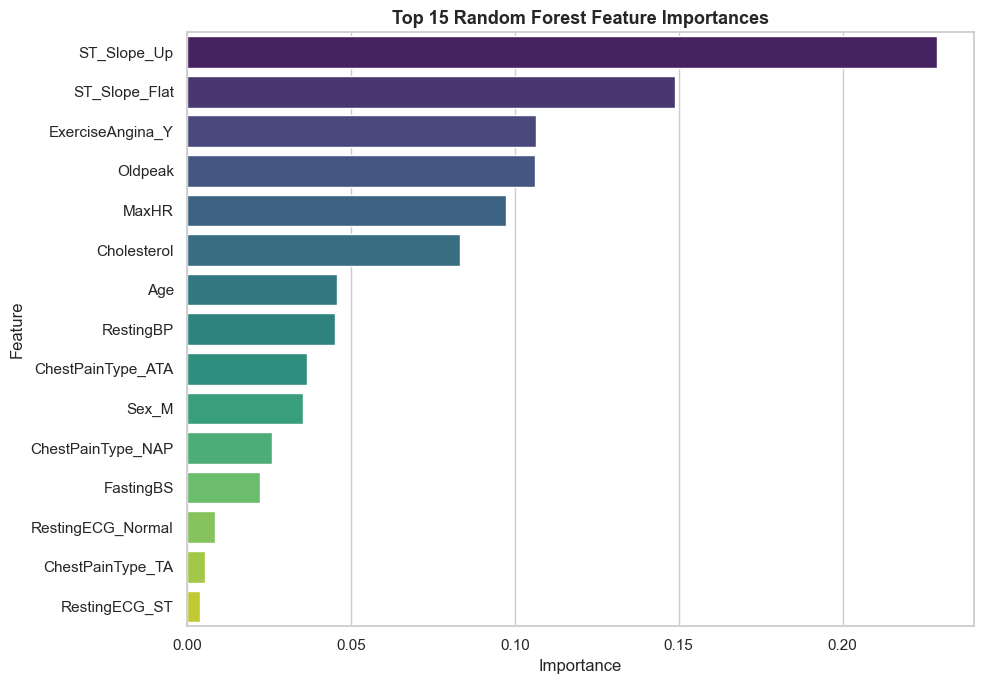

Top 10 Important Features:


,Feature,Importance
14,ST_Slope_Up,0.228686
13,ST_Slope_Flat,0.148938
12,ExerciseAngina_Y,0.106450
5,Oldpeak,0.106205
4,MaxHR,0.097200
2,Cholesterol,0.083334
0,Age,0.045888
1,RestingBP,0.045051
7,ChestPainType_ATA,0.036694
6,Sex_M,0.035318


In [24]:
# Plot Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

top_n = 15
plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance.head(top_n),
    x='Importance',
    y='Feature',
    palette='viridis'
 )
plt.title(f'Top {top_n} Random Forest Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Top 10 Important Features:')
feature_importance.head(10)

## 2.4 K-Means Clustering (Patient Archetypes)

KMeans Model Selection:
   k     inertia  silhouette
0  2  11304.9305      0.1788
1  3  10393.5210      0.1650
2  4   9506.5174      0.1806
3  5   8881.6571      0.1579
4  6   8215.3300      0.1652

Selected k (highest silhouette): 4


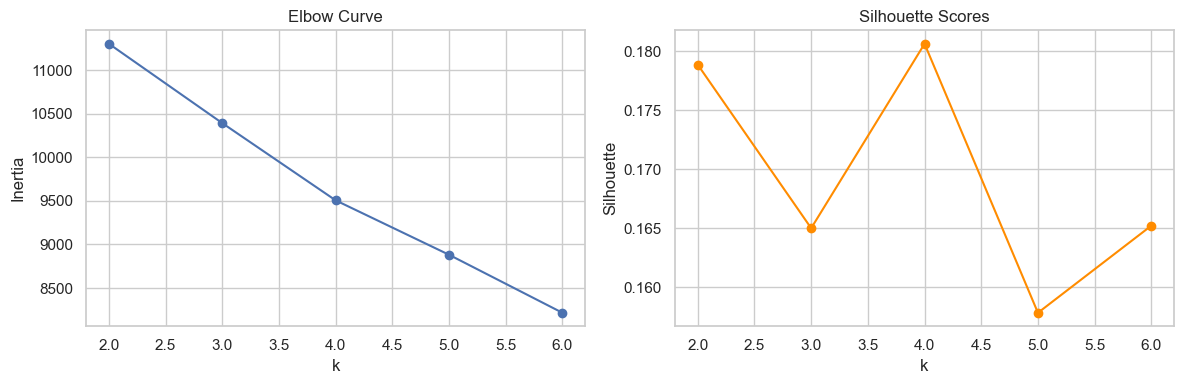


Cluster Size Distribution:
Cluster
0    342
1     46
2    141
3    389
Name: count, dtype: int64

Cluster Clinical Profiles (means):


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,HeartDisease
Cluster,,,,,,
0,49.53,129.32,227.09,151.60,0.23,0.13
1,54.83,136.41,207.07,147.89,1.04,0.43
2,58.69,138.82,155.25,123.36,1.22,0.83
3,54.98,132.30,188.73,127.37,1.33,0.84


In [25]:
# Run K-Means and identify patient cluster profiles

# Use model features (excluding target), then standardize for clustering
cluster_X = X.copy()
scaler = StandardScaler()
cluster_X_scaled = scaler.fit_transform(cluster_X)

# Evaluate candidate k values
k_candidates = range(2, 7)
inertias = []
sil_scores = []

for k in k_candidates:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(cluster_X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(cluster_X_scaled, labels))

best_k = k_candidates[int(np.argmax(sil_scores))]
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(cluster_X_scaled)

df_clusters = df.copy()
df_clusters['Cluster'] = cluster_labels

print('KMeans Model Selection:')
print(pd.DataFrame({
    'k': list(k_candidates),
    'inertia': inertias,
    'silhouette': sil_scores
}).round(4))
print(f'\nSelected k (highest silhouette): {best_k}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_candidates), inertias, marker='o')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_candidates), sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Scores')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

print('\nCluster Size Distribution:')
print(df_clusters['Cluster'].value_counts().sort_index())

cluster_profile = df_clusters.groupby('Cluster')[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']].mean().round(2)
print('\nCluster Clinical Profiles (means):')
display(cluster_profile)

---
# PHASE 3: Evaluation & Insight Generation

## 3.1 Model Evaluation

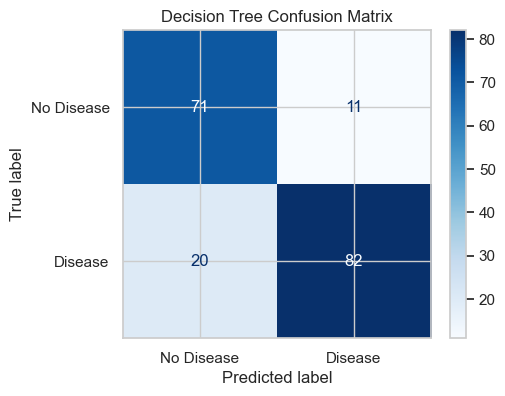

Decision Tree Classification Report:
              precision    recall  f1-score   support

  No Disease       0.78      0.87      0.82        82
     Disease       0.88      0.80      0.84       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.84      0.83      0.83       184



In [26]:
# Confusion Matrix – Decision Tree

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['No Disease', 'Disease'],
    cmap='Blues',
    ax=ax
 )
ax.set_title('Decision Tree Confusion Matrix')
plt.show()

print('Decision Tree Classification Report:')
print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Disease']))

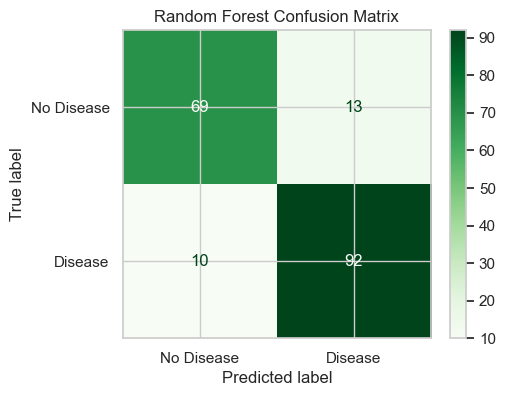

Random Forest Classification Report:
              precision    recall  f1-score   support

  No Disease       0.87      0.84      0.86        82
     Disease       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184



In [27]:
# Confusion Matrix – Random Forest

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['No Disease', 'Disease'],
    cmap='Greens',
    ax=ax
 )
ax.set_title('Random Forest Confusion Matrix')
plt.show()

print('Random Forest Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Disease']))

In [28]:
# Compare Accuracy, Precision, Recall, F1 of both models

model_comparison = pd.DataFrame([
    {
        'Model': 'Decision Tree',
        'Accuracy': accuracy_score(y_test, y_pred_dt),
        'Precision': precision_score(y_test, y_pred_dt),
        'Recall': recall_score(y_test, y_pred_dt),
        'F1': f1_score(y_test, y_pred_dt)
    },
    {
        'Model': 'Random Forest',
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'F1': f1_score(y_test, y_pred_rf)
    }
]).sort_values('Recall', ascending=False).reset_index(drop=True)

print('Model Performance Comparison (sorted by Recall):')
display(model_comparison.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1': '{:.4f}'
}))

best_model_name = model_comparison.loc[0, 'Model']
print(f"\nRecommended model for screening workflow: {best_model_name} (highest Recall)")

Model Performance Comparison (sorted by Recall):


,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.8750,0.8762,0.9020,0.8889
1,Decision Tree,0.8315,0.8817,0.8039,0.8410



Recommended model for screening workflow: Random Forest (highest Recall)


## 3.2 Clinical Insights & Discussion

This section translates the mined results into board-level clinical and operational meaning.

### 1. What the Results Show
- **Random Forest was the strongest screening model** in this project, with **87.5% accuracy** and **90.2% recall** on the held-out test set. In a screening workflow, that means the model is better at catching patients who truly have heart disease, which is the safer trade-off for triage.
- **Decision Tree remained interpretable but weaker**, reaching **83.2% accuracy** and **80.4% recall**. It is useful for explanation, but it misses more true-risk patients than Random Forest.
- **Association rules uncovered clinically sensible risk bundles**. The strongest patterns repeatedly combined **asymptomatic chest pain (ASY)**, **exercise angina**, **flat ST slope**, **moderate ST depression**, and **very low max heart rate**. These are not random statistical artifacts; they match a recognizable high-risk presentation.
- **Risk is multi-factorial**, not driven by a single lab or vital sign. The strongest signals came from combinations of symptoms, exercise response, and ECG-related features rather than one isolated metric.

### 2. Clinical Meaning for the Hospital
- A patient who looks unremarkable on one measure can still be high risk when several subtle signals appear together. That is exactly where manual review often struggles.
- The strongest rule patterns can be used as **early warning flags** at intake or during outpatient review, especially for patients with ASY chest pain plus abnormal exercise/ECG response.
- The cluster results suggest the patient population is not uniform. Some groups show low average disease burden, while others have much higher average disease prevalence and worse physiological profiles. That supports **risk-tiered care pathways** instead of one generic workflow.

### 3. Operational Implications
- **Triage:** Prioritize cardiology review for patients flagged by both the model and the strongest rule combinations.
- **Prevention:** Route moderate-risk groups into counseling, medication review, and follow-up earlier rather than waiting for acute deterioration.
- **Resource allocation:** Use the predicted risk bands and patient clusters to schedule specialist time, stress testing, and follow-up slots more efficiently.
- **Workflow standardization:** Convert the strongest combinations into intake prompts or checklist alerts so subtle high-risk profiles are less likely to be missed.

### 4. Important Safeguards
- These results describe **association and prediction**, not causation.
- The model should be validated on local hospital data before full deployment.
- Performance should be monitored by subgroup, especially age and sex, to reduce the chance of uneven screening quality.
- The model should support, not replace, clinical judgment.

## 3.3 Strategic Recommendation

### Recommended Deployment Strategy
Deploy **Random Forest** as the primary screening model because it delivered the best overall screening balance in this project and the **highest recall (90.2%)**. For hospital use, that is the most important result because missed heart disease cases are more costly than extra review of false positives.

### Why This Is the Best Fit
- It catches more true-risk patients than the Decision Tree.
- It still keeps strong accuracy, so the extra sensitivity does not come at the cost of unusable precision.
- It works well alongside the rule miner: the model estimates risk, and the rules explain *why* the patient looks risky.

### How It Should Be Used
1. Use the dashboard as a **decision-support layer** at intake, not as a standalone diagnosis.
2. Present each result as a simple package: **risk probability, risk band, and top contributing factors**.
3. Trigger a clinician review when the model flags a patient and the rule explorer shows matching high-risk patterns.
4. Keep periodic retraining and quarterly performance review so the system stays aligned with the hospital population.

### Risk Controls
- Maintain physician-in-the-loop review for all high-risk predictions.
- Track recall, precision, and subgroup performance over time.
- Validate the model locally before operational rollout.
- State clearly that the system supports clinical judgment; it does not replace it.